<a href="https://colab.research.google.com/github/RolandoLopez16/RegresionLinealHV/blob/main/ModelosCajaNegraHV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos caja negra para predicción de productividad de equipos Harvester

Este notebook compara tres modelos predictivos de caja negra para estimar la productividad operacional de equipos harvester, medida mediante `M3/HORA`. El flujo se concentra en entrenamiento, validación, optimización, comparación de desempeño y generación de artifacts para una aplicación Streamlit.

Los modelos comparados son:

| Modelo | Enfoque | Propósito dentro del análisis |
|---|---|---|
| Random Forest Regressor | Ensamble de árboles por bagging | Capturar relaciones no lineales con buena robustez frente a variabilidad operacional. |
| XGBoost Regressor | Gradient Boosting secuencial | Evaluar un modelo de alto desempeño para datos tabulares y patrones complejos. |
| LightGBM Regressor | Gradient Boosting eficiente | Comparar una alternativa rápida y escalable para predicción sobre variables transformadas. |

## 1. Configuración inicial del entorno

Se instalan e importan las librerías requeridas para lectura del dataset, preparación de datos, entrenamiento de modelos caja negra, validación cruzada, optimización de hiperparámetros y exportación de artifacts para despliegue.

In [19]:
# ============================================================
# 1. CONFIGURACIÓN INICIAL DEL ENTORNO
# ============================================================

import sys
import subprocess
import importlib
import warnings
warnings.filterwarnings("ignore")


def ensure_package(import_name, pip_spec):
    """Instala un paquete únicamente si no está disponible en el entorno."""
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Instalando dependencia faltante: {pip_spec}")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_spec,
            "--upgrade-strategy", "only-if-needed"
        ])

# Paquetes adicionales. No se fuerza actualización de pandas/numpy para conservar compatibilidad con Colab.
ensure_package("openpyxl", "openpyxl==3.1.5")
ensure_package("requests", "requests==2.32.3")
ensure_package("meteostat", "meteostat==1.6.8")
ensure_package("joblib", "joblib==1.4.2")
ensure_package("xgboost", "xgboost==2.1.4")
ensure_package("lightgbm", "lightgbm==4.5.0")
ensure_package("optuna", "optuna==4.2.1")

from pathlib import Path
from datetime import datetime
import json
import math
import os
import re
import time
from zipfile import ZipFile, ZIP_DEFLATED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
except Exception:
    root_mean_squared_error = None

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib
import requests
try:
    from meteostat import Point, Hourly
except Exception:
    Point, Hourly = None, None

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 10
OPTIMIZATION_CV_SPLITS = 5
N_ITER_RANDOMIZED = 20
N_TRIALS_OPTUNA = 25
RUN_RANDOMIZED_SEARCH = True
RUN_OPTUNA = True

OUTPUT_DIR = Path("outputs_blackbox")
ARTIFACTS_DIR = Path("artifacts_blackbox")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Entorno configurado correctamente.")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Entorno configurado correctamente.
Fecha de ejecución: 2026-05-21 07:20:46


## 2. Módulo auxiliar para artifacts de Streamlit

Se crea un módulo auxiliar con transformadores compatibles con `joblib`. Este archivo debe conservarse junto al modelo exportado para que la aplicación Streamlit pueda cargar correctamente el pipeline entrenado.

In [20]:
# ============================================================
# 2. MÓDULO AUXILIAR PARA ARTIFACTS DE STREAMLIT
# ============================================================

TRANSFORMERS_MODULE_PATH = ARTIFACTS_DIR / "hv_blackbox_transformers.py"

TRANSFORMERS_MODULE_PATH.write_text(
r"""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.lower_bounds_ = X_df.quantile(self.lower_quantile, numeric_only=True)
        self.upper_bounds_ = X_df.quantile(self.upper_quantile, numeric_only=True)
        self.feature_names_in_ = np.array(X_df.columns.astype(str))
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            if col in self.lower_bounds_.index:
                X_df[col] = X_df[col].clip(
                    lower=self.lower_bounds_[col],
                    upper=self.upper_bounds_[col]
                )
        return X_df.values

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.feature_names_in_
        return np.array(input_features, dtype=object)
""",
encoding="utf-8"
)

sys.path.insert(0, str(ARTIFACTS_DIR.resolve()))
from hv_blackbox_transformers import QuantileClipper

print(f"Módulo auxiliar creado en: {TRANSFORMERS_MODULE_PATH}")

Módulo auxiliar creado en: artifacts_blackbox/hv_blackbox_transformers.py


## 3. Carga robusta del dataset

Se carga el archivo Excel desde rutas compatibles con ejecución local y Google Colab. La lectura se realiza sobre la hoja `INFORMEHV`, que contiene los registros operativos de los equipos harvester.

In [21]:
# ============================================================
# 3. CARGA ROBUSTA DEL DATASET
# ============================================================

FILE_NAME = "Dataset_HV_2026_v5.xlsx"
SHEET_NAME = "INFORMEHV"

possible_paths = [
    Path("/mnt/data") / FILE_NAME,
    Path("/content") / FILE_NAME,
    Path.cwd() / FILE_NAME,
    Path(".") / FILE_NAME,
    Path("/mnt/data") / "Dataset_HV_2026.xlsx",
    Path("/content") / "Dataset_HV_2026.xlsx",
    Path.cwd() / "Dataset_HV_2026.xlsx",
    Path(".") / "Dataset_HV_2026.xlsx",
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print("No se encontró el archivo localmente. Seleccione el archivo Dataset_HV_2026_v5.xlsx o Dataset_HV_2026.xlsx.")
        uploaded = files.upload()
        if FILE_NAME in uploaded:
            DATA_PATH = Path("/content") / FILE_NAME
        else:
            DATA_PATH = Path("/content") / next(iter(uploaded.keys()))
    except Exception as exc:
        raise FileNotFoundError(
            f"No se encontró {FILE_NAME}. Coloque el archivo en el mismo directorio del notebook o en /content."
        ) from exc

print(f"Archivo utilizado: {DATA_PATH}")
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]:,} columnas")
display(df_raw.head())

Archivo utilizado: /content/Dataset_HV_2026.xlsx
Dataset cargado: 1,990 filas x 66 columnas


,Efectividad%,Efectividad% Global,DM%,ARBOLES/HORA,VOLUMEN/ÁRBOL,PRODUCTIVIDAD M3/H,Tiempo Efectivo,Horas disponibles,Total Paradas mecanicas,Mantenimiento periódico,Total Paradas Mecanicas Mantenimiento,Total horas de otras paradas,EQUIPO,MARCA,OPERADOR,CEDULA,ZONA,CONTRATISTA,FECHA,FINCA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia,Longitud Sexa finca,Latitud Sexa finca,Municipio Finca,PENDIENTE PROMEDIO FINCA,ESPECIE,LOTE,TURNO,HORA INICIO TURNO,HORA FIN TURNO,PENDIENTE,TOTAL DE ARBOLES,M3,M3/HORA,FUSTES/HORA,DIAMETRO,T PROGRAMADO,T PARADAS MEC,ESPECIFICACION PARADA,REF REPUESTO,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,NOVEDADES,SUELO,HORAS DE OTRAS PARADA,T OTRA PARADA 1,T OTRA PARADA2,T OTRA PARADA3,T OTRA PARADA 4,T OTRA PARADA 5,MOTIVO 1,MOTIVO 2,MOTIVO 3,MOTIVO 4,MOTIVO 5,Unnamed: 64,Unnamed: 65
0,0.8824,0.6250,0.7083,28.5300,0.3100,8.9300,7.5000,8.5000,3.5000,0,0.5000,0.0000,HVPO-4,PONSSE,HAROL OROZCO,4582961,CENTRO,EFAGRAM,2026-01-13,35ALEJA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76°16'08.8''W,4°26'03.0''N,Bolivar,27.3109,Eucalyptus grandis,1.0000,TURNO 1,06:00:00,14:00:00,20,214,67.0000,8.9300,0.0000,18.0000,12.0000,3.0000,NaN,Winche,0.5000,0.2500,0.7500,0.0000,NaN,HUMEDO,4.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.8065,0.3125,0.3875,19.2000,0.1000,2.0000,2.5000,3.1000,4.9000,0,0.3000,0.0000,HVPO-3,PONSSE,Brian Valencia,1022124531,Norte,EFAGRAM,2026-01-02,12PERLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°46'38.6''W,5°21'05.1''N,Guatica,17.4275,Eucalyptus grandis,2.0000,TURNO 2,14:00:00,22:00:00,35,48,5.0000,2.0000,9.0000,16.0000,8.0000,4.6000,Esperando reparación,Winche,0.3000,0.3000,0.3000,0.0000,"Se procesa madera tumbada por motosierrista, s...",Humedo,5.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.9434,0.8962,0.9500,42.6800,0.2500,10.4700,7.1700,7.6000,0.4000,0,0.2000,0.0000,HVPO-3,PONSSE,Jhon Chaverra,1039884146,NORTE,EFAGRAM,2026-01-20,12PALMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°45'30.2''W,5°22'59.0''N,Guatica,17.4321,Eucalyptus grandis,8.0000,TURNO 1,06:00:00,14:00:00,32,306,75.0500,10.4700,0.0000,19.0000,8.0000,0.2000,En reparación,Winche,0.2000,0.2000,0.2300,8.0000,SE REVISA WINCHE DEL EQUIPO,HUMEDO,0.8300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0000,0.8538,0.8538,16.5400,0.3600,5.9600,6.8300,6.8300,1.1700,0,0.1700,0.0000,HVPO-3,PONSSE,BRIAN VALENCIA,1022124531,NORTE,EFAGRAM,2026-02-01,12ARGEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°44'43.0''W,5°24'09.9''N,Riosucio,16.1293,Pinus tecunumanii,6.0000,TURNO 2,14:00:00,22:00:00,15,113,40.7000,5.9600,0.0000,30.0000,8.0000,1.0000,En reparación,Winche,0.1700,0.0000,0.0000,1.0000,SE INICIA TURNO REALIZANDO AJUSTE AL CABLE DEL...,HUMEDO,1.1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.9717,0.7923,0.8154,21.7500,0.5400,11.7000,5.1500,5.3000,1.2000,0,0.3800,0.0000,HVPO-1,PONSSE,JOHNIER RUIZ,4516297,NORTE,GREEN FOREST,2026-03-08,13SNGER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°52'57.2''W,4°13'34.6''N,Sevilla,35.0868,Pinus tecunumanii,6.0000,TURNO 2,14:00:00,22:00:00,32,112,60.2600,11.7000,36.0000,0.0000,6.5000,0.8200,Esperando reparación,Winche,0.3800,0.0000,0.1500,0.0000,NaN,HUMEDO,1.3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Comprensión inicial del dataset

Se revisa la estructura general de la base para confirmar dimensiones, tipos de datos, valores faltantes, duplicados y cobertura temporal disponible para el modelado predictivo.

In [22]:
# ============================================================
# 4. COMPRENSIÓN INICIAL DEL DATASET
# ============================================================

df = df_raw.copy()

summary = pd.DataFrame({
    "variable": df.columns,
    "tipo_dato": [str(df[c].dtype) for c in df.columns],
    "valores_no_nulos": [df[c].notna().sum() for c in df.columns],
    "valores_nulos": [df[c].isna().sum() for c in df.columns],
    "porcentaje_nulos": [df[c].isna().mean() * 100 for c in df.columns],
    "valores_unicos": [df[c].nunique(dropna=True) for c in df.columns],
})

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
print(f"Duplicados exactos: {df.duplicated().sum():,}")

if "FECHA" in df.columns:
    fecha_tmp = pd.to_datetime(df["FECHA"], errors="coerce")
    print(f"Fecha mínima: {fecha_tmp.min()}")
    print(f"Fecha máxima: {fecha_tmp.max()}")

display(summary)

Filas: 1,990
Columnas: 66
Duplicados exactos: 10
Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-05-15 00:00:00


,variable,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
0,Efectividad%,float64,1990,0,0.0000,1056
1,Efectividad% Global,float64,1986,4,0.2010,740
2,DM%,float64,1990,0,0.0000,361
3,ARBOLES/HORA,float64,1689,301,15.1256,1368
4,VOLUMEN/ÁRBOL,float64,1566,424,21.3065,108
5,PRODUCTIVIDAD M3/H,float64,1990,0,0.0000,1149
6,Tiempo Efectivo,float64,1990,0,0.0000,645
7,Horas disponibles,float64,1990,0,0.0000,290
8,Total Paradas mecanicas,float64,1990,0,0.0000,261
9,Mantenimiento periódico,int64,1990,0,0.0000,1


## 5. Definición de variable objetivo y variables predictoras

Se define `M3/HORA` como variable objetivo. Las variables predictoras corresponden a factores operativos, forestales, geográficos, temporales y climáticos. La productividad duplicada y variables derivadas del resultado se excluyen del entrenamiento para conservar validez predictiva.

In [23]:
# ============================================================
# 5. DEFINICIÓN DE VARIABLE OBJETIVO Y VARIABLES PREDICTORAS
# ============================================================

TARGET_COL = "M3/HORA"
DUPLICATE_TARGET_COL = "PRODUCTIVIDAD M3/H"

if TARGET_COL not in df.columns:
    raise ValueError(f"No se encontró la variable objetivo esperada: {TARGET_COL}")

categorical_features_base = [
    "EQUIPO",
    "MARCA",
    "ZONA",
    "CONTRATISTA",
    "FINCA",
    "Municipio Finca",
    "ESPECIE",
    "TURNO",
    "SUELO",
]

numeric_features_base = [
    "PENDIENTE PROMEDIO FINCA",
    "TOTAL DE ARBOLES",
    "DIAMETRO",
    "T PROGRAMADO",
    "T PARADAS MEC",
    "T Paradas Mec Mantenimiento",
    "HORAS DE OTRAS PARADA",
    "ALISTAMIENTO",
    "TANQUEO",
    "ALIMENTACIÓN",
    "T USO WINCHE",
]

date_features = [
    "MES",
    "DIA_SEMANA",
    "SEMANA_ANIO",
]

climate_features_expected = [
    "clima_temp_promedio_dia_c",
    "clima_temp_min_dia_c",
    "clima_temp_max_dia_c",
    "clima_precipitacion_dia_mm",
    "clima_viento_promedio_dia_kmh",
    "clima_presion_promedio_dia_hpa",
    "clima_horas_validas_dia",
    "clima_horas_lluvia_dia",
]

excluded_from_model = [
    "PRODUCTIVIDAD M3/H",
    "M3",
    "T EFECTIVO",
    "ARB/HORA",
    "FUSTES/HORA",
    "VOL/ÁRBOL",
    "E%",
    "E% Global",
    "DM%",
    "Horas disponibles",
    "Ttal P. mec",
    "CEDULA",
    "OPERADOR",
    "NOVEDADES",
    "ESPECIFICACION PARADA",
    "REF REPUESTO",
    "Mantenimiento periódico",
    "T OTRA PARADA 1",
    "T OTRA PARADA2",
    "T OTRA PARADA3",
    "T OTRA PARADA 4",
    "T OTRA PARADA 5",
    "MOTIVO 1",
    "MOTIVO 2",
    "MOTIVO 3",
    "MOTIVO 4",
    "MOTIVO 5",
    "Unnamed: 64",
    "Unnamed: 65",
    "PENDIENTE",
]

categorical_features = [c for c in categorical_features_base if c in df.columns]
numeric_features = [c for c in numeric_features_base if c in df.columns]

if DUPLICATE_TARGET_COL in df.columns:
    target_main = pd.to_numeric(df[TARGET_COL], errors="coerce")
    target_duplicate = pd.to_numeric(df[DUPLICATE_TARGET_COL], errors="coerce")
    duplicate_equal_rate = np.isclose(target_main, target_duplicate, equal_nan=True).mean()
    print(f"Coincidencia entre '{TARGET_COL}' y '{DUPLICATE_TARGET_COL}': {duplicate_equal_rate:.2%}")

feature_plan = pd.DataFrame({
    "grupo": (
        ["Categórica"] * len(categorical_features)
        + ["Numérica operativa"] * len(numeric_features)
        + ["Temporal derivada"] * len(date_features)
        + ["Climática esperada"] * len(climate_features_expected)
        + ["Excluida"] * len(excluded_from_model)
    ),
    "variable": (
        categorical_features
        + numeric_features
        + date_features
        + climate_features_expected
        + excluded_from_model
    )
})

display(feature_plan)

Coincidencia entre 'M3/HORA' y 'PRODUCTIVIDAD M3/H': 100.00%


,grupo,variable
0,Categórica,EQUIPO
1,Categórica,MARCA
2,Categórica,ZONA
3,Categórica,CONTRATISTA
4,Categórica,FINCA
5,Categórica,Municipio Finca
6,Categórica,ESPECIE
7,Categórica,TURNO
8,Categórica,SUELO
9,Numérica operativa,PENDIENTE PROMEDIO FINCA


## 6. Limpieza inicial y creación de variables temporales

Se normalizan categorías, se convierten variables numéricas, se procesa la fecha y se derivan campos temporales para representar patrones de operación por mes, día de semana y semana del año.

In [24]:
# ============================================================
# 6. LIMPIEZA INICIAL Y CREACIÓN DE VARIABLES TEMPORALES
# ============================================================

df_clean = df.copy()

def clean_category_value(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value.upper()

if "FECHA" not in df_clean.columns:
    raise ValueError("No se encontró la columna FECHA.")

df_clean["FECHA"] = pd.to_datetime(df_clean["FECHA"], errors="coerce")
df_clean[TARGET_COL] = pd.to_numeric(df_clean[TARGET_COL], errors="coerce")

for col in categorical_features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_category_value)

for col in numeric_features + climate_features_expected:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean["MES"] = df_clean["FECHA"].dt.month
df_clean["DIA_SEMANA"] = df_clean["FECHA"].dt.dayofweek
df_clean["SEMANA_ANIO"] = df_clean["FECHA"].dt.isocalendar().week.astype("Int64")

print("Dimensión posterior a limpieza inicial:")
print(df_clean.shape)
display(df_clean[["FECHA", "MES", "DIA_SEMANA", "SEMANA_ANIO", TARGET_COL]].head())

Dimensión posterior a limpieza inicial:
(1990, 69)


,FECHA,MES,DIA_SEMANA,SEMANA_ANIO,M3/HORA
0,2026-01-13,1,1,3,8.9300
1,2026-01-02,1,4,1,2.0000
2,2026-01-20,1,1,4,10.4700
3,2026-02-01,2,6,5,5.9600
4,2026-03-08,3,6,10,11.7000


## 7. Preparación de coordenadas geográficas

Se transforman las coordenadas de finca desde formato sexagesimal hacia formato decimal. Estas coordenadas se utilizan para consultar variables climáticas por ubicación y fecha.

In [25]:
# ============================================================
# 7. PREPARACIÓN DE COORDENADAS GEOGRÁFICAS
# ============================================================

LAT_COL = "Latitud Sexa finca"
LON_COL = "Longitud Sexa finca"

def dms_to_decimal(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().upper()
    s = (
        s.replace("º", "°")
         .replace("”", '"')
         .replace("“", '"')
         .replace("’", "'")
         .replace("''", '"')
    )

    direction_match = re.findall(r"[NSEW]", s)
    direction = direction_match[-1] if direction_match else ""

    nums = re.findall(r"[-+]?\d+(?:\.\d+)?", s)
    if len(nums) >= 3:
        degrees = float(nums[0])
        minutes = float(nums[1])
        seconds = float(nums[2])
        decimal = abs(degrees) + minutes / 60 + seconds / 3600
    elif len(nums) == 1:
        decimal = abs(float(nums[0]))
    else:
        return np.nan

    if direction in ["S", "W"]:
        decimal *= -1

    return decimal

if LAT_COL in df_clean.columns and LON_COL in df_clean.columns:
    df_clean["latitud_decimal"] = df_clean[LAT_COL].apply(dms_to_decimal)
    df_clean["longitud_decimal"] = df_clean[LON_COL].apply(dms_to_decimal)
else:
    df_clean["latitud_decimal"] = np.nan
    df_clean["longitud_decimal"] = np.nan

df_clean["lat_round"] = df_clean["latitud_decimal"].round(5)
df_clean["lon_round"] = df_clean["longitud_decimal"].round(5)
df_clean["FECHA_DIA"] = pd.to_datetime(df_clean["FECHA"]).dt.normalize()

coord_cols = [c for c in ["FINCA", LAT_COL, LON_COL, "latitud_decimal", "longitud_decimal"] if c in df_clean.columns]
display(df_clean[coord_cols].drop_duplicates().head(20))
print("Registros con coordenadas válidas:", df_clean[["latitud_decimal", "longitud_decimal"]].notna().all(axis=1).sum())

,FINCA,Latitud Sexa finca,Longitud Sexa finca,latitud_decimal,longitud_decimal
0,35ALEJA,4°26'03.0''N,76°16'08.8''W,4.4342,-76.2691
1,12PERLA,5°21'05.1''N,75°46'38.6''W,5.3514,-75.7774
2,12PALMA,5°22'59.0''N,75°45'30.2''W,5.3831,-75.7584
3,12ARGEN,5°24'09.9''N,75°44'43.0''W,5.4028,-75.7453
4,13SNGER,4°13'34.6''N,75°52'57.2''W,4.2263,-75.8826
6,15RIEL_,4°50'48.0''N,75°37'12.0''W,4.8467,-75.6200
7,31GRACI,4°04'11.9''N,76°24'26.8''W,4.0700,-76.4074
8,13SINAB,4°06'28.8''N,75°52'33.4''W,4.1080,-75.8759
10,34ESTRE,3°51'37.6''N,76°29'55.3''W,3.8604,-76.4987
11,34BRILL,3°51'56.4''N,76°28'57.7''W,3.8657,-76.4827


Registros con coordenadas válidas: 1990


## 8. Integración de variables climáticas

Se consulta información climática diaria por coordenada y fecha. La fuente principal es Open-Meteo; NASA POWER y Meteostat se utilizan como fuentes de respaldo cuando la consulta principal no retorna datos.

In [26]:
# ============================================================
# 8. INTEGRACIÓN DE VARIABLES CLIMÁTICAS
# ============================================================

ENABLE_CLIMATE_ENRICHMENT = True
ENABLE_NASA_POWER_FALLBACK = True
ENABLE_METEOSTAT_FALLBACK = True
FORCE_REFRESH_CLIMATE = False

CLIMATE_CACHE_PATH = OUTPUT_DIR / "clima_harvester_cache_blackbox.csv"

def _safe_request_json(url, params, timeout=45, max_retries=3, sleep_seconds=1.5):
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=timeout)
            response.raise_for_status()
            return response.json()
        except Exception:
            if attempt == max_retries - 1:
                return None
            time.sleep(sleep_seconds)
    return None

def query_open_meteo_hourly(lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": float(lat),
        "longitude": float(lon),
        "start_date": pd.to_datetime(start_date).strftime("%Y-%m-%d"),
        "end_date": pd.to_datetime(end_date).strftime("%Y-%m-%d"),
        "hourly": "temperature_2m,precipitation,wind_speed_10m,pressure_msl",
        "timezone": "auto",
    }

    data = _safe_request_json(url, params)
    if not data or "hourly" not in data or "time" not in data["hourly"]:
        return pd.DataFrame()

    hourly = pd.DataFrame(data["hourly"])
    if hourly.empty:
        return pd.DataFrame()

    hourly["datetime"] = pd.to_datetime(hourly["time"], errors="coerce")
    hourly["FECHA_DIA"] = hourly["datetime"].dt.normalize()

    for c in ["temperature_2m", "precipitation", "wind_speed_10m", "pressure_msl"]:
        if c in hourly.columns:
            hourly[c] = pd.to_numeric(hourly[c], errors="coerce")

    daily = hourly.groupby("FECHA_DIA").agg(
        clima_temp_promedio_dia_c=("temperature_2m", "mean"),
        clima_temp_min_dia_c=("temperature_2m", "min"),
        clima_temp_max_dia_c=("temperature_2m", "max"),
        clima_precipitacion_dia_mm=("precipitation", "sum"),
        clima_viento_promedio_dia_kmh=("wind_speed_10m", "mean"),
        clima_presion_promedio_dia_hpa=("pressure_msl", "mean"),
        clima_horas_validas_dia=("temperature_2m", "count"),
        clima_horas_lluvia_dia=("precipitation", lambda x: (pd.to_numeric(x, errors="coerce") > 0).sum()),
    ).reset_index()

    daily["fuente_clima"] = "OPEN_METEO"
    return daily

def query_nasa_power_daily(lat, lon, start_date, end_date):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,T2M_MIN,T2M_MAX,PRECTOTCORR,WS2M,PS",
        "community": "AG",
        "longitude": float(lon),
        "latitude": float(lat),
        "start": pd.to_datetime(start_date).strftime("%Y%m%d"),
        "end": pd.to_datetime(end_date).strftime("%Y%m%d"),
        "format": "JSON",
    }

    data = _safe_request_json(url, params)
    try:
        params_data = data["properties"]["parameter"]
    except Exception:
        return pd.DataFrame()

    records = []
    all_dates = sorted(set().union(*[set(v.keys()) for v in params_data.values() if isinstance(v, dict)]))
    for d in all_dates:
        records.append({
            "FECHA_DIA": pd.to_datetime(d, format="%Y%m%d", errors="coerce"),
            "clima_temp_promedio_dia_c": params_data.get("T2M", {}).get(d, np.nan),
            "clima_temp_min_dia_c": params_data.get("T2M_MIN", {}).get(d, np.nan),
            "clima_temp_max_dia_c": params_data.get("T2M_MAX", {}).get(d, np.nan),
            "clima_precipitacion_dia_mm": params_data.get("PRECTOTCORR", {}).get(d, np.nan),
            "clima_viento_promedio_dia_kmh": params_data.get("WS2M", {}).get(d, np.nan),
            "clima_presion_promedio_dia_hpa": params_data.get("PS", {}).get(d, np.nan),
            "clima_horas_validas_dia": 24,
            "clima_horas_lluvia_dia": np.nan,
            "fuente_clima": "NASA_POWER",
        })

    daily = pd.DataFrame(records)
    for col in climate_features_expected:
        if col in daily.columns:
            daily[col] = pd.to_numeric(daily[col], errors="coerce").replace(-999, np.nan)
    return daily

def query_meteostat_hourly(lat, lon, start_date, end_date):
    if Point is None or Hourly is None:
        return pd.DataFrame()
    try:
        point = Point(float(lat), float(lon))
        data = Hourly(
            point,
            pd.to_datetime(start_date).to_pydatetime(),
            pd.to_datetime(end_date).to_pydatetime()
        ).fetch()
        if data.empty:
            return pd.DataFrame()
        hourly = data.reset_index()
        hourly["FECHA_DIA"] = pd.to_datetime(hourly["time"], errors="coerce").dt.normalize()
        daily = hourly.groupby("FECHA_DIA").agg(
            clima_temp_promedio_dia_c=("temp", "mean"),
            clima_temp_min_dia_c=("temp", "min"),
            clima_temp_max_dia_c=("temp", "max"),
            clima_precipitacion_dia_mm=("prcp", "sum"),
            clima_viento_promedio_dia_kmh=("wspd", "mean"),
            clima_presion_promedio_dia_hpa=("pres", "mean"),
            clima_horas_validas_dia=("temp", "count"),
            clima_horas_lluvia_dia=("prcp", lambda x: (pd.to_numeric(x, errors="coerce") > 0).sum()),
        ).reset_index()
        daily["fuente_clima"] = "METEOSTAT"
        return daily
    except Exception:
        return pd.DataFrame()

def build_climate_dataset(df_input):
    required = ["lat_round", "lon_round", "FECHA_DIA"]
    if not all(c in df_input.columns for c in required):
        return pd.DataFrame()

    location_df = (
        df_input.dropna(subset=["lat_round", "lon_round", "FECHA_DIA"])
        .groupby(["lat_round", "lon_round"], as_index=False)
        .agg(fecha_min=("FECHA_DIA", "min"), fecha_max=("FECHA_DIA", "max"))
    )

    print(f"Ubicaciones climáticas a consultar: {len(location_df):,}")
    all_weather = []
    for _, row in location_df.iterrows():
        lat = row["lat_round"]
        lon = row["lon_round"]
        start_date = row["fecha_min"]
        end_date = row["fecha_max"]

        weather = query_open_meteo_hourly(lat, lon, start_date, end_date)
        if weather.empty and ENABLE_NASA_POWER_FALLBACK:
            weather = query_nasa_power_daily(lat, lon, start_date, end_date)
        if weather.empty and ENABLE_METEOSTAT_FALLBACK:
            weather = query_meteostat_hourly(lat, lon, start_date, end_date)
        if not weather.empty:
            weather["lat_round"] = lat
            weather["lon_round"] = lon
            all_weather.append(weather)

    if not all_weather:
        return pd.DataFrame()
    return pd.concat(all_weather, ignore_index=True).drop_duplicates(subset=["lat_round", "lon_round", "FECHA_DIA"])

if ENABLE_CLIMATE_ENRICHMENT:
    if CLIMATE_CACHE_PATH.exists() and not FORCE_REFRESH_CLIMATE:
        climate_data = pd.read_csv(CLIMATE_CACHE_PATH, parse_dates=["FECHA_DIA"])
        print(f"Datos climáticos cargados desde caché: {CLIMATE_CACHE_PATH}")
    else:
        climate_data = build_climate_dataset(df_clean)
        if not climate_data.empty:
            climate_data.to_csv(CLIMATE_CACHE_PATH, index=False, encoding="utf-8-sig")
            print(f"Datos climáticos guardados en caché: {CLIMATE_CACHE_PATH}")
else:
    climate_data = pd.DataFrame()

print("Dimensión de datos climáticos:")
print(climate_data.shape)
display(climate_data.head())

Datos climáticos cargados desde caché: outputs_blackbox/clima_harvester_cache_blackbox.csv
Dimensión de datos climáticos:
(1871, 12)


,FECHA_DIA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia,fuente_clima,lat_round,lon_round
0,2026-01-21,21.9375,18.0000,28.5000,10.3000,5.4125,"1,010.5208",24,17,OPEN_METEO,3.0605,-76.5219
1,2026-01-22,20.5750,19.0000,25.2000,26.6000,4.1000,"1,012.0625",24,20,OPEN_METEO,3.0605,-76.5219
2,2026-01-23,22.0167,18.7000,27.2000,3.5000,4.3958,"1,012.0750",24,11,OPEN_METEO,3.0605,-76.5219
3,2026-01-24,22.0000,18.8000,27.6000,7.7000,3.9417,"1,011.9125",24,16,OPEN_METEO,3.0605,-76.5219
4,2026-01-25,21.7917,18.6000,28.0000,29.7000,4.7250,"1,013.0875",24,18,OPEN_METEO,3.0605,-76.5219


## 9. Consolidación de variables climáticas

Se integran las variables climáticas consultadas al dataset operativo. Luego se valida su cobertura para incorporar al modelo únicamente las variables climáticas con datos disponibles.

In [27]:
# ============================================================
# 9. CONSOLIDACIÓN DE VARIABLES CLIMÁTICAS
# ============================================================

for col in climate_features_expected:
    if col not in df_clean.columns:
        df_clean[col] = np.nan

if not climate_data.empty:
    climate_merge = climate_data.copy()
    df_clean = df_clean.merge(
        climate_merge,
        on=["lat_round", "lon_round", "FECHA_DIA"],
        how="left",
        suffixes=("", "_api")
    )

    for col in climate_features_expected:
        api_col = f"{col}_api"
        if api_col in df_clean.columns:
            df_clean[col] = df_clean[col].combine_first(df_clean[api_col])

    if "fuente_clima" not in df_clean.columns and "fuente_clima_api" in df_clean.columns:
        df_clean["fuente_clima"] = df_clean["fuente_clima_api"]
    elif "fuente_clima_api" in df_clean.columns:
        df_clean["fuente_clima"] = df_clean.get("fuente_clima", pd.Series(index=df_clean.index, dtype=object)).combine_first(df_clean["fuente_clima_api"])

    api_cols_to_drop = [c for c in df_clean.columns if c.endswith("_api")]
    df_clean = df_clean.drop(columns=api_cols_to_drop, errors="ignore")

climate_quality = pd.DataFrame({
    "variable": climate_features_expected,
    "valores_no_nulos": [df_clean[c].notna().sum() if c in df_clean.columns else 0 for c in climate_features_expected],
    "porcentaje_cobertura": [df_clean[c].notna().mean() * 100 if c in df_clean.columns else 0 for c in climate_features_expected],
})

climate_features_valid = [
    c for c in climate_features_expected
    if c in df_clean.columns and df_clean[c].notna().sum() > 0
]

display(climate_quality)
print("Variables climáticas válidas para modelado:")
print(climate_features_valid)

,variable,valores_no_nulos,porcentaje_cobertura
0,clima_temp_promedio_dia_c,1990,100.0000
1,clima_temp_min_dia_c,1990,100.0000
2,clima_temp_max_dia_c,1990,100.0000
3,clima_precipitacion_dia_mm,1990,100.0000
4,clima_viento_promedio_dia_kmh,1990,100.0000
5,clima_presion_promedio_dia_hpa,1990,100.0000
6,clima_horas_validas_dia,1990,100.0000
7,clima_horas_lluvia_dia,1990,100.0000


Variables climáticas válidas para modelado:
['clima_temp_promedio_dia_c', 'clima_temp_min_dia_c', 'clima_temp_max_dia_c', 'clima_precipitacion_dia_mm', 'clima_viento_promedio_dia_kmh', 'clima_presion_promedio_dia_hpa', 'clima_horas_validas_dia', 'clima_horas_lluvia_dia']


## 10. Preparación del dataset analítico

Se construye la base final para entrenamiento. Se conservan registros válidos de productividad, se controla la presencia de valores extremos de la variable objetivo mediante IQR y se separan predictores y objetivo.

In [28]:
# ============================================================
# 10. PREPARACIÓN DEL DATASET ANALÍTICO
# ============================================================

categorical_model_features = [c for c in categorical_features if c in df_clean.columns]
numeric_model_features = [
    c for c in (numeric_features + date_features + climate_features_valid)
    if c in df_clean.columns
]
model_features = categorical_model_features + numeric_model_features

if len(model_features) == 0:
    raise ValueError("No se identificaron variables predictoras válidas para el modelo.")

df_model = df_clean.copy()
df_model = df_model[df_model[TARGET_COL].notna()].copy()
df_model = df_model[df_model[TARGET_COL] > 0].copy()

q1 = df_model[TARGET_COL].quantile(0.25)
q3 = df_model[TARGET_COL].quantile(0.75)
iqr = q3 - q1
target_lower_bound = q1 - 1.5 * iqr
target_upper_bound = q3 + 1.5 * iqr

df_model["target_outlier_iqr"] = (
    (df_model[TARGET_COL] < target_lower_bound)
    | (df_model[TARGET_COL] > target_upper_bound)
)

df_model = df_model[~df_model["target_outlier_iqr"]].copy()

for col in numeric_model_features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

for col in categorical_model_features:
    df_model[col] = df_model[col].apply(clean_category_value)

X_model = df_model[model_features].copy()
y_model = df_model[TARGET_COL].copy()

print("Dimensión dataset analítico:")
print(f"X: {X_model.shape}")
print(f"y: {y_model.shape}")
print("Variables categóricas usadas:", categorical_model_features)
print("Variables numéricas usadas:", numeric_model_features)
display(df_model[[TARGET_COL] + model_features].head())

Dimensión dataset analítico:
X: (1575, 30)
y: (1575,)
Variables categóricas usadas: ['EQUIPO', 'MARCA', 'ZONA', 'CONTRATISTA', 'FINCA', 'Municipio Finca', 'ESPECIE', 'TURNO', 'SUELO']
Variables numéricas usadas: ['PENDIENTE PROMEDIO FINCA', 'TOTAL DE ARBOLES', 'DIAMETRO', 'T PROGRAMADO', 'T PARADAS MEC', 'HORAS DE OTRAS PARADA', 'ALISTAMIENTO', 'TANQUEO', 'ALIMENTACIÓN', 'T USO WINCHE', 'MES', 'DIA_SEMANA', 'SEMANA_ANIO', 'clima_temp_promedio_dia_c', 'clima_temp_min_dia_c', 'clima_temp_max_dia_c', 'clima_precipitacion_dia_mm', 'clima_viento_promedio_dia_kmh', 'clima_presion_promedio_dia_hpa', 'clima_horas_validas_dia', 'clima_horas_lluvia_dia']


,M3/HORA,EQUIPO,MARCA,ZONA,CONTRATISTA,FINCA,Municipio Finca,ESPECIE,TURNO,SUELO,PENDIENTE PROMEDIO FINCA,TOTAL DE ARBOLES,DIAMETRO,T PROGRAMADO,T PARADAS MEC,HORAS DE OTRAS PARADA,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,MES,DIA_SEMANA,SEMANA_ANIO,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia
0,8.9300,HVPO-4,PONSSE,CENTRO,EFAGRAM,35ALEJA,BOLIVAR,EUCALYPTUS GRANDIS,TURNO 1,HUMEDO,27.3109,214,18.0000,12.0000,3.0000,4.5000,0.5000,0.2500,0.7500,0.0000,1,1,3,13.9250,12.0000,18.7000,10.7000,3.4958,"1,014.2750",24,13
1,2.0000,HVPO-3,PONSSE,NORTE,EFAGRAM,12PERLA,GUATICA,EUCALYPTUS GRANDIS,TURNO 2,HUMEDO,17.4275,48,16.0000,8.0000,4.6000,5.5000,0.3000,0.3000,0.3000,0.0000,1,4,1,15.2333,13.6000,17.9000,11.4000,3.1167,"1,014.9125",24,18
2,10.4700,HVPO-3,PONSSE,NORTE,EFAGRAM,12PALMA,GUATICA,EUCALYPTUS GRANDIS,TURNO 1,HUMEDO,17.4321,306,19.0000,8.0000,0.2000,0.8300,0.2000,0.2000,0.2300,8.0000,1,1,4,15.0333,12.8000,20.7000,9.2000,4.0417,"1,014.1917",24,18
3,5.9600,HVPO-3,PONSSE,NORTE,EFAGRAM,12ARGEN,RIOSUCIO,PINUS TECUNUMANII,TURNO 2,HUMEDO,16.1293,113,30.0000,8.0000,1.0000,1.1700,0.1700,0.0000,0.0000,1.0000,2,6,5,13.5875,12.6000,16.4000,34.7000,2.8000,"1,018.1250",24,24
4,11.7000,HVPO-1,PONSSE,NORTE,GREEN FOREST,13SNGER,SEVILLA,PINUS TECUNUMANII,TURNO 2,HUMEDO,35.0868,112,0.0000,6.5000,0.8200,1.3500,0.3800,0.0000,0.1500,0.0000,3,6,10,15.5292,12.6000,19.3000,20.3000,3.2792,"1,012.8500",24,14


## 11. División entrenamiento-prueba

Se separa el dataset en entrenamiento y prueba. El conjunto de prueba queda reservado para medir el desempeño final de los modelos sobre datos no utilizados durante el entrenamiento.

In [29]:
# ============================================================
# 11. DIVISIÓN ENTRENAMIENTO-PRUEBA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]:,} registros")
print(f"Prueba: {X_test.shape[0]:,} registros")

Entrenamiento: 1,260 registros
Prueba: 315 registros


## 12. Pipeline de preprocesamiento

Se define un pipeline reproducible para imputar valores faltantes, controlar extremos en variables numéricas y transformar variables categóricas mediante One-Hot Encoding. Este pipeline se integra directamente con cada modelo de caja negra.

In [30]:
# ============================================================
# 12. PIPELINE DE PREPROCESAMIENTO
# ============================================================

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower_quantile=0.01, upper_quantile=0.99)),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_model_features),
        ("cat", categorical_pipeline, categorical_model_features),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

print("Pipeline de preprocesamiento definido correctamente.")

Pipeline de preprocesamiento definido correctamente.


## 13. Funciones de evaluación

Se definen funciones comunes para calcular MAE, RMSE y R². Estas métricas permiten comparar todos los modelos bajo el mismo criterio de desempeño predictivo.

In [31]:
# ============================================================
# 13. FUNCIONES DE EVALUACIÓN
# ============================================================

def rmse_score(y_true, y_pred):
    if root_mean_squared_error is not None:
        return root_mean_squared_error(y_true, y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def evaluate_model(model, X_eval, y_eval, model_name, etapa="Prueba"):
    pred = model.predict(X_eval)
    return {
        "modelo": model_name,
        "etapa": etapa,
        "MAE": mean_absolute_error(y_eval, pred),
        "RMSE": rmse_score(y_eval, pred),
        "R2": r2_score(y_eval, pred),
    }

def evaluate_cv(model, X, y, model_name, cv):
    results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
        },
        n_jobs=-1,
        return_train_score=False,
    )
    return {
        "modelo": model_name,
        "MAE_CV_promedio": -results["test_MAE"].mean(),
        "MAE_CV_desviacion": results["test_MAE"].std(),
        "RMSE_CV_promedio": -results["test_RMSE"].mean(),
        "RMSE_CV_desviacion": results["test_RMSE"].std(),
        "R2_CV_promedio": results["test_R2"].mean(),
        "R2_CV_desviacion": results["test_R2"].std(),
    }

kfold = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
optimization_kfold = KFold(n_splits=OPTIMIZATION_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print("Funciones de evaluación definidas correctamente.")

Funciones de evaluación definidas correctamente.


## 14. Definición de modelos caja negra

Se construyen los tres modelos base a comparar: Random Forest, XGBoost y LightGBM. Cada modelo se encapsula en un pipeline con el mismo preprocesamiento para asegurar una comparación consistente.

In [32]:
# ============================================================
# 14. DEFINICIÓN DE MODELOS CAJA NEGRA
# ============================================================

base_model_specs = {
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.90,
        colsample_bytree=0.90,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
}

base_models = {
    name: Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", clone(model))
    ])
    for name, model in base_model_specs.items()
}

print("Modelos base definidos:")
print(list(base_models.keys()))

Modelos base definidos:
['Random Forest', 'XGBoost', 'LightGBM']


## 15. Entrenamiento y evaluación inicial

Se entrenan los tres modelos base y se evalúan sobre el conjunto de prueba. Esta comparación inicial permite identificar el desempeño predictivo sin optimización de hiperparámetros.

In [33]:
# ============================================================
# 15. ENTRENAMIENTO Y EVALUACIÓN INICIAL
# ============================================================

trained_base_models = {}
metrics_records = []

for name, model in base_models.items():
    print(f"Entrenando modelo base: {name}")
    model.fit(X_train, y_train)
    trained_base_models[name] = model
    metrics_records.append(evaluate_model(model, X_test, y_test, f"{name} base"))

metrics_table = pd.DataFrame(metrics_records).sort_values("MAE").reset_index(drop=True)
display(metrics_table)

Entrenando modelo base: Random Forest
Entrenando modelo base: XGBoost
Entrenando modelo base: LightGBM


,modelo,etapa,MAE,RMSE,R2
0,XGBoost base,Prueba,2.7922,3.9952,0.6318
1,LightGBM base,Prueba,2.8087,4.0665,0.6185
2,Random Forest base,Prueba,3.0387,4.2723,0.5790


## 16. Validación cruzada de modelos base

Se aplica validación cruzada K-Fold para evaluar la estabilidad de los modelos base en diferentes particiones del dataset.

In [34]:
# ============================================================
# 16. VALIDACIÓN CRUZADA DE MODELOS BASE
# ============================================================

cv_records = []
for name, model in base_models.items():
    print(f"Validando con K-Fold: {name}")
    cv_records.append(evaluate_cv(model, X_model, y_model, f"{name} base", kfold))

cv_table = pd.DataFrame(cv_records).sort_values("MAE_CV_promedio").reset_index(drop=True)
display(cv_table)

Validando con K-Fold: Random Forest
Validando con K-Fold: XGBoost
Validando con K-Fold: LightGBM


,modelo,MAE_CV_promedio,MAE_CV_desviacion,RMSE_CV_promedio,RMSE_CV_desviacion,R2_CV_promedio,R2_CV_desviacion
0,XGBoost base,2.6530,0.1832,3.7032,0.3889,0.6644,0.0684
1,LightGBM base,2.6771,0.1898,3.7423,0.3687,0.6588,0.0596
2,Random Forest base,2.8899,0.1462,3.9598,0.3313,0.6198,0.0473


## 17. Comparación inicial de modelos

Se consolida la evaluación inicial con la validación cruzada para observar simultáneamente el error en prueba y la estabilidad promedio de cada modelo.

In [35]:
# ============================================================
# 17. COMPARACIÓN INICIAL DE MODELOS
# ============================================================

comparison_initial = metrics_table.merge(cv_table, on="modelo", how="left")
comparison_initial = comparison_initial.sort_values("MAE").reset_index(drop=True)
display(comparison_initial)

,modelo,etapa,MAE,RMSE,R2,MAE_CV_promedio,MAE_CV_desviacion,RMSE_CV_promedio,RMSE_CV_desviacion,R2_CV_promedio,R2_CV_desviacion
0,XGBoost base,Prueba,2.7922,3.9952,0.6318,2.6530,0.1832,3.7032,0.3889,0.6644,0.0684
1,LightGBM base,Prueba,2.8087,4.0665,0.6185,2.6771,0.1898,3.7423,0.3687,0.6588,0.0596
2,Random Forest base,Prueba,3.0387,4.2723,0.5790,2.8899,0.1462,3.9598,0.3313,0.6198,0.0473


## 18. Optimización con Randomized Search

Se aplica búsqueda aleatoria de hiperparámetros para explorar configuraciones relevantes de cada modelo. La métrica de optimización es el MAE, debido a su interpretación directa en unidades de productividad.

In [42]:
# ============================================================
# 18. OPTIMIZACIÓN CON RANDOMIZED SEARCH
# ============================================================

randomized_models = {}
randomized_records = []
randomized_best_params = {}

param_distributions = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500, 700],
        "model__max_depth": [None, 6, 10, 16, 24],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.7, 1.0],
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 500, 700],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__subsample": [0.70, 0.80, 0.90, 1.00],
        "model__colsample_bytree": [0.70, 0.80, 0.90, 1.00],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__reg_alpha": [0.0, 0.01, 0.10, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    },
    "LightGBM": {
        "model__n_estimators": [200, 300, 500, 700],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
        "model__num_leaves": [15, 31, 63, 95],
        "model__max_depth": [-1, 4, 6, 10, 16],
        "model__min_child_samples": [10, 20, 30, 50],
        "model__subsample": [0.70, 0.80, 0.90, 1.00],
        "model__colsample_bytree": [0.70, 0.80, 0.90, 1.00],
        "model__reg_alpha": [0.0, 0.01, 0.10, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    },
}

if RUN_RANDOMIZED_SEARCH:
    for name, model in base_models.items():
        print(f"Optimizando con Randomized Search: {name}")
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_distributions[name],
            n_iter=N_ITER_RANDOMIZED,
            scoring="neg_mean_absolute_error",
            cv=optimization_kfold,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        search.fit(X_train, y_train)
        best_estimator = search.best_estimator_
        randomized_models[f"{name} Randomized Search"] = best_estimator
        randomized_best_params[f"{name} Randomized Search"] = search.best_params_
        randomized_records.append(evaluate_model(best_estimator, X_test, y_test, f"{name} Randomized Search"))
else:
    print("Randomized Search desactivado.")

randomized_table = pd.DataFrame(randomized_records).sort_values("MAE").reset_index(drop=True) if randomized_records else pd.DataFrame()
display(randomized_table)

Optimizando con Randomized Search: Random Forest
Optimizando con Randomized Search: XGBoost
Optimizando con Randomized Search: LightGBM


,modelo,etapa,MAE,RMSE,R2
0,XGBoost Randomized Search,Prueba,2.7308,3.9823,0.6342
1,LightGBM Randomized Search,Prueba,2.8019,4.0413,0.6233
2,Random Forest Randomized Search,Prueba,3.0214,4.2421,0.5849


## 19. Optimización bayesiana con Optuna

Se aplica optimización bayesiana para buscar hiperparámetros de manera eficiente. El procedimiento minimiza el MAE promedio en validación cruzada.

In [36]:
# ============================================================
# 19. OPTIMIZACIÓN BAYESIANA CON OPTUNA
# ============================================================

optuna_models = {}
optuna_records = []
optuna_best_params = {}


def build_blackbox_pipeline(model_name, params):
    if model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    elif model_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            min_child_weight=params["min_child_weight"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
    elif model_name == "LightGBM":
        model = LGBMRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            num_leaves=params["num_leaves"],
            max_depth=params["max_depth"],
            min_child_samples=params["min_child_samples"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    else:
        raise ValueError(f"Modelo no reconocido: {model_name}")

    return Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", model),
    ])


def suggest_params(trial, model_name):
    if model_name == "Random Forest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
            "max_depth": trial.suggest_categorical("max_depth", [None, 6, 10, 16, 24, 32]),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 12),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.7, 1.0]),
        }
    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 7),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 8.0, log=True),
        }
    if model_name == "LightGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127),
            "max_depth": trial.suggest_categorical("max_depth", [-1, 4, 6, 10, 16, 24]),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 8.0, log=True),
        }
    raise ValueError(f"Modelo no reconocido: {model_name}")

if RUN_OPTUNA:
    for model_name in ["Random Forest", "XGBoost", "LightGBM"]:
        print(f"Optimizando con Optuna: {model_name}")

        def objective(trial, current_model=model_name):
            params = suggest_params(trial, current_model)
            pipeline = build_blackbox_pipeline(current_model, params)
            scores = cross_val_score(
                pipeline,
                X_train,
                y_train,
                scoring="neg_mean_absolute_error",
                cv=optimization_kfold,
                n_jobs=-1,
            )
            return -scores.mean()

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        )
        study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=False)

        best_params = study.best_params
        best_pipeline = build_blackbox_pipeline(model_name, best_params)
        best_pipeline.fit(X_train, y_train)

        model_label = f"{model_name} Optuna"
        optuna_models[model_label] = best_pipeline
        optuna_best_params[model_label] = best_params
        optuna_records.append(evaluate_model(best_pipeline, X_test, y_test, model_label))
else:
    print("Optuna desactivado.")

optuna_table = pd.DataFrame(optuna_records).sort_values("MAE").reset_index(drop=True) if optuna_records else pd.DataFrame()
display(optuna_table)

Optimizando con Optuna: Random Forest
Optimizando con Optuna: XGBoost
Optimizando con Optuna: LightGBM


,modelo,etapa,MAE,RMSE,R2
0,LightGBM Optuna,Prueba,2.8248,4.0591,0.6199
1,XGBoost Optuna,Prueba,2.8303,4.0425,0.6230
2,Random Forest Optuna,Prueba,3.0712,4.3167,0.5702


## 20. Comparación final y selección del mejor modelo

Se consolidan los resultados de modelos base y optimizados. La selección se realiza con prioridad en menor MAE sobre el conjunto de prueba, complementado con RMSE y R².

In [ ]:
# ============================================================
# 20. COMPARACIÓN FINAL Y SELECCIÓN DEL MEJOR MODELO
# ============================================================

candidate_models = {}
candidate_models.update({f"{name} base": model for name, model in trained_base_models.items()})
candidate_models.update(randomized_models)
candidate_models.update(optuna_models)

all_metrics = [metrics_table]
if not randomized_table.empty:
    all_metrics.append(randomized_table)
if not optuna_table.empty:
    all_metrics.append(optuna_table)

final_metrics_table = pd.concat(all_metrics, ignore_index=True)
final_metrics_table = final_metrics_table.drop_duplicates(subset=["modelo"], keep="last")
final_metrics_table = final_metrics_table.sort_values(["MAE", "RMSE"], ascending=[True, True]).reset_index(drop=True)

display(final_metrics_table)

best_model_name = final_metrics_table.iloc[0]["modelo"]
best_model = candidate_models[best_model_name]

print(f"Modelo seleccionado por menor MAE en prueba: {best_model_name}")

## 21. Validación cruzada del modelo seleccionado

Se aplica validación cruzada al modelo seleccionado para estimar su estabilidad predictiva sobre diferentes particiones del dataset completo.

In [ ]:
# ============================================================
# 21. VALIDACIÓN CRUZADA DEL MODELO SELECCIONADO
# ============================================================

best_model_cv_summary = pd.DataFrame([
    evaluate_cv(best_model, X_model, y_model, best_model_name, kfold)
])

display(best_model_cv_summary)

## 22. Diagnóstico de predicción del mejor modelo

Se revisa la relación entre productividad real y productividad predicha, así como la distribución de errores. Este diagnóstico evalúa el comportamiento predictivo del modelo seleccionado sin analizar la importancia individual de variables.

,PRODUCTIVIDAD_REAL_M3_HORA,PRODUCTIVIDAD_PREDICHA_M3_HORA,ERROR,ERROR_ABSOLUTO,ERROR_PORCENTUAL_ABS
count,315.0000,315.0000,315.0000,315.0000,315.0000
mean,13.4588,13.3719,0.0869,2.7308,26.6115
std,6.5947,5.2261,3.9877,2.9031,44.3890
min,0.9800,2.0069,-14.4875,0.0073,0.1282
25%,8.6350,9.4940,-2.0965,0.8741,7.3689
50%,12.2800,12.6801,-0.2972,1.9303,15.8211
75%,17.2200,16.8386,1.7339,3.7139,29.5371
max,32.9100,26.7170,27.6447,27.6447,410.7178


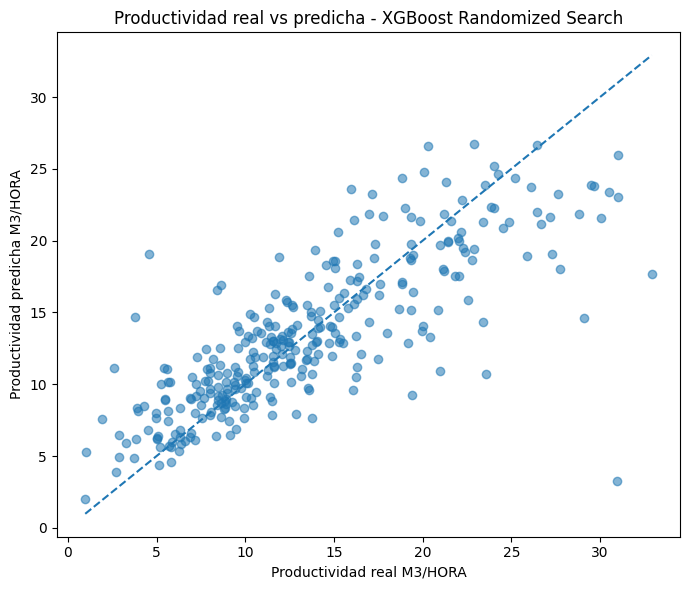

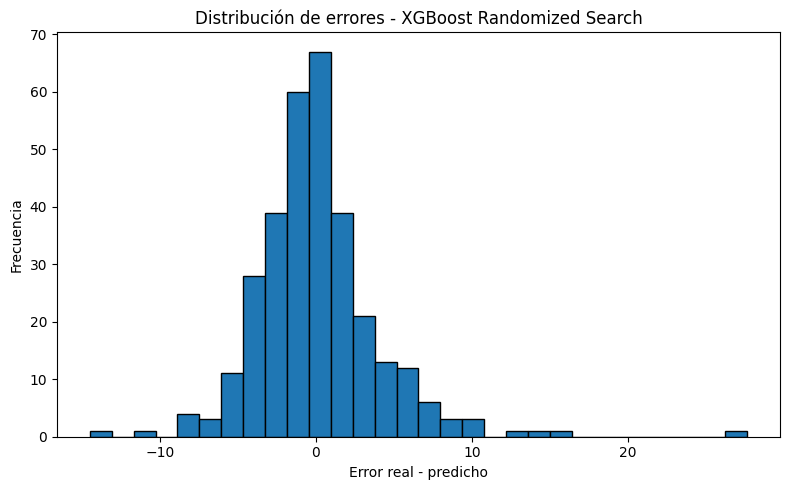

In [39]:
# ============================================================
# 22. DIAGNÓSTICO DE PREDICCIÓN DEL MEJOR MODELO
# ============================================================

y_pred_best = best_model.predict(X_test)
residuals_best = y_test - y_pred_best

prediction_diagnostics = pd.DataFrame({
    "PRODUCTIVIDAD_REAL_M3_HORA": y_test.values,
    "PRODUCTIVIDAD_PREDICHA_M3_HORA": y_pred_best,
    "ERROR": residuals_best.values,
    "ERROR_ABSOLUTO": np.abs(residuals_best.values),
    "ERROR_PORCENTUAL_ABS": np.where(
        y_test.values != 0,
        np.abs(residuals_best.values) / y_test.values * 100,
        np.nan,
    )
}, index=y_test.index)

display(prediction_diagnostics.describe())

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.55)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title(f"Productividad real vs predicha - {best_model_name}")
plt.xlabel("Productividad real M3/HORA")
plt.ylabel("Productividad predicha M3/HORA")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals_best, bins=30, edgecolor="black")
plt.title(f"Distribución de errores - {best_model_name}")
plt.xlabel("Error real - predicho")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 23. Exportación de artifacts para Streamlit

Se entrena el mejor modelo con el dataset analítico completo y se generan únicamente los artifacts requeridos para una aplicación Streamlit: modelo, metadata, columnas, categorías, dataset de referencia, métricas y archivo comprimido para descarga masiva.

In [40]:
# ============================================================
# 23. EXPORTACIÓN DE ARTIFACTS PARA STREAMLIT
# ============================================================

final_model_for_deploy = clone(best_model)
final_model_for_deploy.fit(X_model, y_model)

model_path = ARTIFACTS_DIR / "modelo_blackbox_productividad_harvester.pkl"
metadata_path = ARTIFACTS_DIR / "metadata_blackbox_modelo.json"
columns_path = ARTIFACTS_DIR / "columnas_blackbox_modelo.json"
categories_path = ARTIFACTS_DIR / "categorias_blackbox_modelo.json"
reference_dataset_path = ARTIFACTS_DIR / "dataset_referencia_blackbox_streamlit.csv"
metrics_path = ARTIFACTS_DIR / "metricas_blackbox_modelos.csv"
cv_selected_path = ARTIFACTS_DIR / "validacion_cruzada_blackbox_modelo_seleccionado.csv"
prediction_sample_path = ARTIFACTS_DIR / "predicciones_blackbox_prueba.csv"
params_path = ARTIFACTS_DIR / "hiperparametros_blackbox_modelos.json"

joblib.dump(final_model_for_deploy, model_path)

categorias_modelo = {
    col: sorted(df_model[col].dropna().astype(str).unique().tolist())
    for col in categorical_model_features
}

best_params_consolidated = {}
best_params_consolidated.update(randomized_best_params)
best_params_consolidated.update(optuna_best_params)

metadata = {
    "nombre_modelo": "Modelo caja negra de productividad Harvester",
    "modelo_seleccionado": best_model_name,
    "variable_objetivo": TARGET_COL,
    "variables_categoricas": categorical_model_features,
    "variables_numericas": numeric_model_features,
    "variables_climaticas_validas": climate_features_valid,
    "variables_modelo": model_features,
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "registros_modelo": int(len(df_model)),
    "registros_entrenamiento": int(len(X_train)),
    "registros_prueba": int(len(X_test)),
    "criterio_seleccion": "Menor MAE en conjunto de prueba, con revisión complementaria de RMSE y R2.",
    "metricas_modelos": final_metrics_table.to_dict(orient="records"),
    "validacion_cruzada_modelo_seleccionado": best_model_cv_summary.to_dict(orient="records"),
    "limite_iqr_target_inferior": float(target_lower_bound),
    "limite_iqr_target_superior": float(target_upper_bound),
    "archivo_modelo": str(model_path),
    "archivo_columnas": str(columns_path),
    "archivo_categorias": str(categories_path),
    "archivo_dataset_referencia": str(reference_dataset_path),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

with open(columns_path, "w", encoding="utf-8") as f:
    json.dump(model_features, f, ensure_ascii=False, indent=4)

with open(categories_path, "w", encoding="utf-8") as f:
    json.dump(categorias_modelo, f, ensure_ascii=False, indent=4)

with open(params_path, "w", encoding="utf-8") as f:
    json.dump(best_params_consolidated, f, ensure_ascii=False, indent=4, default=str)

reference_cols = model_features + [TARGET_COL]
df_model[reference_cols].head(300).to_csv(reference_dataset_path, index=False, encoding="utf-8-sig")
final_metrics_table.to_csv(metrics_path, index=False, encoding="utf-8-sig")
best_model_cv_summary.to_csv(cv_selected_path, index=False, encoding="utf-8-sig")
prediction_diagnostics.to_csv(prediction_sample_path, index=True, encoding="utf-8-sig")

exported_files = pd.DataFrame({
    "tipo": [
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
    ],
    "archivo": [
        str(model_path),
        str(metadata_path),
        str(columns_path),
        str(categories_path),
        str(reference_dataset_path),
        str(metrics_path),
        str(cv_selected_path),
        str(prediction_sample_path),
        str(TRANSFORMERS_MODULE_PATH),
    ]
})

zip_path = ARTIFACTS_DIR / "artifacts_blackbox_streamlit_harvester.zip"
with ZipFile(zip_path, "w", compression=ZIP_DEFLATED) as zipf:
    for file_str in exported_files["archivo"].tolist() + [str(params_path)]:
        file_path = Path(file_str)
        if file_path.exists():
            zipf.write(file_path, arcname=file_path.name)

zip_row = pd.DataFrame({
    "tipo": ["Paquete artifacts Streamlit"],
    "archivo": [str(zip_path)]
})

exported_files_final = pd.concat([exported_files, zip_row], ignore_index=True)
display(exported_files_final)

print("Artifacts para Streamlit generados correctamente.")
print(f"Archivo ZIP generado: {zip_path}")

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("No se detectó entorno Google Colab. El ZIP quedó disponible en la ruta indicada.")

,tipo,archivo
0,Streamlit artifact,artifacts_blackbox/modelo_blackbox_productivid...
1,Streamlit artifact,artifacts_blackbox/metadata_blackbox_modelo.json
2,Streamlit artifact,artifacts_blackbox/columnas_blackbox_modelo.json
3,Streamlit artifact,artifacts_blackbox/categorias_blackbox_modelo....
4,Streamlit artifact,artifacts_blackbox/dataset_referencia_blackbox...
5,Streamlit artifact,artifacts_blackbox/metricas_blackbox_modelos.csv
6,Streamlit artifact,artifacts_blackbox/validacion_cruzada_blackbox...
7,Streamlit artifact,artifacts_blackbox/predicciones_blackbox_prueb...
8,Streamlit artifact,artifacts_blackbox/hv_blackbox_transformers.py
9,Paquete artifacts Streamlit,artifacts_blackbox/artifacts_blackbox_streamli...


Artifacts para Streamlit generados correctamente.
Archivo ZIP generado: artifacts_blackbox/artifacts_blackbox_streamlit_harvester.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 24. Conclusiones técnicas del notebook

Se sintetizan los resultados de comparación entre modelos caja negra. El texto generado permite incorporar al documento académico la selección del modelo, las métricas de desempeño y la utilidad predictiva del enfoque.

In [41]:
# ============================================================
# 24. CONCLUSIONES TÉCNICAS DEL NOTEBOOK
# ============================================================

best_row = final_metrics_table.iloc[0]
conclusion_text = f"""
### Conclusiones técnicas

El ejercicio comparativo permitió evaluar modelos predictivos de caja negra para estimar la productividad de equipos harvester, medida en M3/HORA. Los modelos considerados fueron Random Forest, XGBoost y LightGBM, incluyendo versiones base y versiones optimizadas mediante búsqueda aleatoria y optimización bayesiana.

El modelo con mejor desempeño en el conjunto de prueba fue **{best_model_name}**, con un MAE de **{best_row['MAE']:.4f}**, un RMSE de **{best_row['RMSE']:.4f}** y un R² de **{best_row['R2']:.4f}**. Estos resultados indican el nivel de error esperado al estimar la productividad bajo las condiciones operativas, forestales, geográficas, temporales y climáticas disponibles en el dataset.

La validación cruzada del modelo seleccionado permitió complementar la evaluación sobre el conjunto de prueba y revisar su estabilidad predictiva en diferentes particiones de los datos. En términos aplicados, el modelo seleccionado puede utilizarse como artifact de predicción en una aplicación Streamlit, permitiendo estimar productividad a partir de registros operativos con la misma estructura del dataset analítico.
"""

display(Markdown(conclusion_text))


### Conclusiones técnicas

El ejercicio comparativo permitió evaluar modelos predictivos de caja negra para estimar la productividad de equipos harvester, medida en M3/HORA. Los modelos considerados fueron Random Forest, XGBoost y LightGBM, incluyendo versiones base y versiones optimizadas mediante búsqueda aleatoria y optimización bayesiana.

El modelo con mejor desempeño en el conjunto de prueba fue **XGBoost Randomized Search**, con un MAE de **2.7308**, un RMSE de **3.9823** y un R² de **0.6342**. Estos resultados indican el nivel de error esperado al estimar la productividad bajo las condiciones operativas, forestales, geográficas, temporales y climáticas disponibles en el dataset.

La validación cruzada del modelo seleccionado permitió complementar la evaluación sobre el conjunto de prueba y revisar su estabilidad predictiva en diferentes particiones de los datos. En términos aplicados, el modelo seleccionado puede utilizarse como artifact de predicción en una aplicación Streamlit, permitiendo estimar productividad a partir de registros operativos con la misma estructura del dataset analítico.
